

# fix  - find notes on how we wanted to generate the dataset, then make it for this

# fix - expand to full dataset usage
# fix - count tracks per composer

In [1]:
# 1. Install system dependencies for MIDI synthesis
!apt-get install -y fluidsynth

# 2. Download a SoundFont (Essential for MIDI -> Audio conversion)
# This downloads the standard General User GS SoundFont
!wget https://github.com/urish/c-flute/raw/master/font/GeneralUser%20GS%20v1.471.sf2 -O /content/font.sf2

# 3. Install Python libraries
!pip install torch torchaudio transformers librosa numpy pandas matplotlib seaborn scikit-learn pretty_midi pyfluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
--2026-03-20 08:35:21--  https://github.com/urish/c-flute/raw/master/font/GeneralUser%20GS%20v1.471.sf2
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-20 08:35:22 ERROR 404: Not Found.



In [2]:
import os
import torch
import numpy as np
import pandas as pd
import librosa
import pretty_midi
from transformers import AutoModel, AutoProcessor

In [3]:
# 1. Clone the repository to get the MIDI files
# Replace 'username' and 'repo' with your actual GitHub details
!git clone https://github.com/mperumal-usd/capstone_team_3

# 2. Move into that directory so the relative paths in your code match
# temporary virtual machine storage
os.chdir('/content/capstone_team_3')

fatal: destination path 'capstone_team_3' already exists and is not an empty directory.


In [4]:
########################################
# Section 0 - Load models and libraries
########################################


# Load MERT model
model_name = "m-a-p/MERT-v1-95M"

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

model.eval()

print("MERT model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT model loaded successfully


In [5]:
##########################
# Section 1 - MIDI to audio
# MERT requires audio, so MIDI must be synthesized.
##########################

import pretty_midi
import librosa
import numpy as np

# Reference MIDI (true Fur Elise)
ref_midi_path = "MidiDatasets/590-Classical-music-midi/beeth/elise.mid"

# Input MIDIs to compare
input_midi_paths = [
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_4thVerse_K-Amin_T-79_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_4thVerse_K-Gmin_T-63_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro_K-Amaj_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro_K-Amin_T-138_righthand_swing.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro_K-Cmaj_T-70_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_Intro_K-Cmin_T-60_righthand.mid",
]

In [6]:
##########################
# Section 2 - MIDI chunking for embeddings
##########################

import pretty_midi
import numpy as np

# Convert MIDI → audio waveform (required for MERT)
def midi_to_audio(midi_path, sr=24000):
    midi = pretty_midi.PrettyMIDI(midi_path)

    # We must provide the path to the .sf2 file we downloaded in step 1
    # On Colab, this path will be '/content/font.sf2'
    audio = midi.fluidsynth(fs=sr, sf2_path='/content/font.sf2')

    return audio, sr


# low, med, high chunk sizes (low,med,high sec in duration)
def chunk_audio(audio, sr, chunk_seconds_list=[2, 7, 15]):
    chunks = []
    chunk_labels = []
    for chunk_seconds in chunk_seconds_list:
        chunk_size = int(sr * chunk_seconds)
        for i in range(0, len(audio), chunk_size):
            chunk = audio[i:i+chunk_size]
            if len(chunk) == chunk_size:
                chunks.append(chunk)
                chunk_labels.append(chunk_seconds)  # track the chunk size
    return chunks, chunk_labels

# Adding MERT embeddings
def embed_chunks(chunks, sr=24000):

    embeddings = []

    for chunk in chunks:

        inputs = processor(
            chunk,
            sampling_rate=sr,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(**inputs)

        # Mean pooling over time dimension
        emb = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

        embeddings.append(emb)

    return embeddings

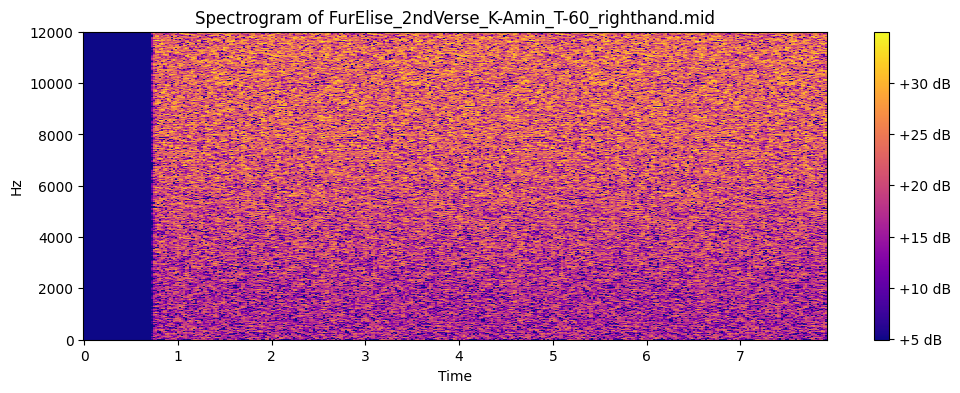

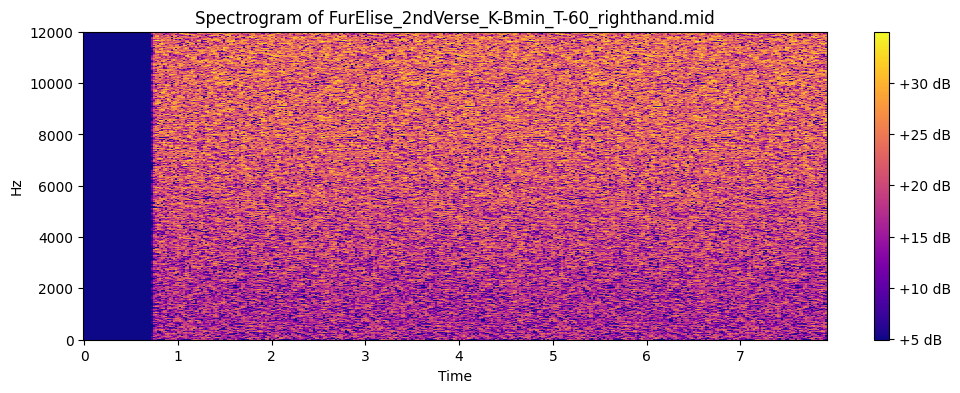

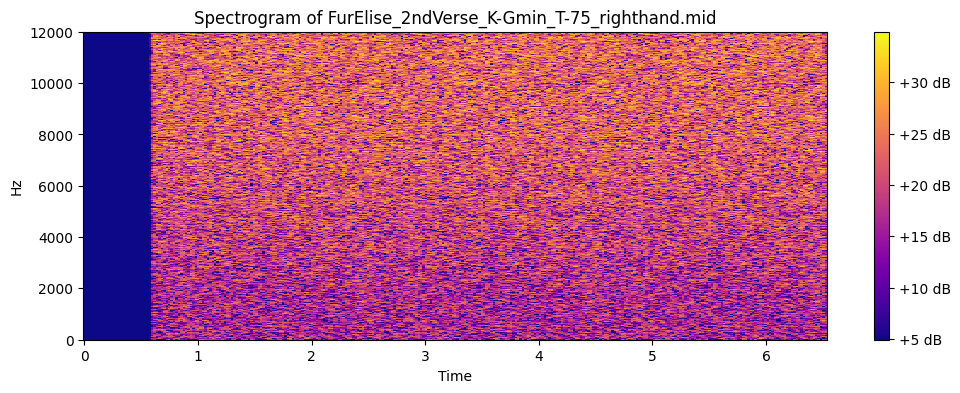

In [7]:
##########################
# Spectrogram visualization
##########################
import warnings

# Ignore the specific deprecation warning from pretty_midi
# pretty_midi version doesn’t yet support the new Synthesizer API
# so sf2_path works safely despite the deprecation.
warnings.filterwarnings(
    "ignore",
    message="The parameter 'sf2_path' is deprecated.*"
)


import matplotlib.pyplot as plt
import librosa.display

# Example: visualize the reference MIDI
audio, sr = midi_to_audio(ref_midi_path)

# Compute STFT (spectrogram)
for path in input_midi_paths[:3]:  # first 3 for quick check
    audio, sr = midi_to_audio(path)
    D = librosa.stft(audio)
    S_db = librosa.amplitude_to_db(np.abs(D), top_db=30)
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='plasma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram of {path.split('/')[-1]}")
    plt.show()

### Section 3 — Similarity Score Computation

MERT similarity computes the overall score

Separate computations are made for pitch, tempo, duration, scale

the MERT embeddings’ overall score mostly captures spectral and timbral similarity (how the audio “sounds” in terms of pitch, harmonics, and general signal structure). It doesn’t explicitly measure rhythm, tempo, or note timing.

So it’s a good to compute these separately:

Tempo similarity – compares the global tempo between reference and input.

Duration / rhythm similarity – uses onset envelopes to see if note timing matches.

Pitch similarity – checks how the pitch content aligns (e.g., via chroma).

Scale / key similarity – optional but useful for harmonic consistency.

Then combine these (combined_score) to get a more complete evaluation.

In [8]:
##########################
# Section 3 - Compute similarities
##########################
import warnings

# Ignore the specific deprecation warning from pretty_midi
# pretty_midi version doesn’t yet support the new Synthesizer API
# so sf2_path works safely despite the deprecation.
warnings.filterwarnings(
    "ignore",
    message="The parameter 'sf2_path' is deprecated.*"
)

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import librosa

results = []

# Reference embedding
print("Converting reference MIDI to audio...")
ref_audio, sr = midi_to_audio(ref_midi_path)
# Chunk reference audio
print("Chunking reference audio...")
ref_chunks = chunk_audio(ref_audio, sr)


# Compute embeddings with progress bar
from tqdm import tqdm

print("Computing reference embeddings (this may take a while)...")
# Chunk reference audio
ref_chunks, ref_chunk_labels = chunk_audio(ref_audio, sr)

# Compute embeddings and store corresponding chunk size
ref_embeds = []
ref_embeds_labels = []
for chunk, label in tqdm(zip(ref_chunks, ref_chunk_labels), desc="Reference embeddings", total=len(ref_chunks)):
    inputs = processor(chunk, sampling_rate=sr, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    ref_embeds.append(emb)
    ref_embeds_labels.append(label)  # store chunk size

# Precompute reference features (do this once)
ref_chroma = librosa.feature.chroma_stft(y=ref_audio, sr=sr)
ref_onset = librosa.onset.onset_strength(y=ref_audio, sr=sr)
ref_tempo, _ = librosa.beat.beat_track(y=ref_audio, sr=sr)

def cosine_sim(a, b):
    return cosine_similarity(a.reshape(1,-1), b.reshape(1,-1))[0][0]


for path in tqdm(input_midi_paths, desc="Calculating Reference to Input Similarities..."):
    audio, sr = midi_to_audio(path)

    # --- MERT embeddings ---
    input_chunks, input_chunk_labels = chunk_audio(audio, sr)
    input_embeds = []
    for chunk in input_chunks:
        inputs = processor(chunk, sampling_rate=sr, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        input_embeds.append(emb)

    if len(ref_embeds) == 0 or len(input_embeds) == 0:
        print("Skipping (too short):", path)
        continue

    sims = []
    for ref_emb in ref_embeds:
        best = max(cosine_sim(ref_emb, inp_emb) for inp_emb in input_embeds)
        sims.append(best)

    sims = np.array(sims)
    overall_embedding_score = np.mean(sims)  # MERT embeddings only

    # --- Pitch similarity (chroma over time) ---
    inp_chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    min_frames = min(ref_chroma.shape[1], inp_chroma.shape[1])
    pitch_sim = cosine_similarity(
        ref_chroma[:, :min_frames].flatten().reshape(1,-1),
        inp_chroma[:, :min_frames].flatten().reshape(1,-1)
    )[0][0]

    # --- Scale similarity (global key distribution) ---
    scale_sim = cosine_similarity(
        ref_chroma.mean(axis=1).reshape(1,-1),
        inp_chroma.mean(axis=1).reshape(1,-1)
    )[0][0]

    # --- Duration / rhythm similarity (onset envelope) ---
    inp_onset = librosa.onset.onset_strength(y=audio, sr=sr)
    min_len = min(len(ref_onset), len(inp_onset))
    duration_sim = cosine_similarity(
        ref_onset[:min_len].reshape(1,-1),
        inp_onset[:min_len].reshape(1,-1)
    )[0][0]

    # --- Tempo similarity ---
    inp_tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)
    tempo_sim = 1 - abs(ref_tempo - inp_tempo) / max(ref_tempo, inp_tempo)

    # --- Store results per chunk ---
    for inp_emb, label in zip(input_embeds, input_chunk_labels):
        sims = [cosine_sim(ref_emb, inp_emb) for ref_emb in ref_embeds]
        overall_embedding_score = np.mean(sims)

        # Pitch similarity (for full audio, optional: keep per chunk if needed)
        inp_chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        min_frames = min(ref_chroma.shape[1], inp_chroma.shape[1])
        pitch_sim = cosine_similarity(
            ref_chroma[:, :min_frames].flatten().reshape(1,-1),
            inp_chroma[:, :min_frames].flatten().reshape(1,-1)
        )[0][0]

        # Scale similarity
        scale_sim = cosine_similarity(
            ref_chroma.mean(axis=1).reshape(1,-1),
            inp_chroma.mean(axis=1).reshape(1,-1)
        )[0][0]

        # Duration / rhythm similarity
        inp_onset = librosa.onset.onset_strength(y=audio, sr=sr)
        min_len = min(len(ref_onset), len(inp_onset))
        duration_sim = cosine_similarity(
            ref_onset[:min_len].reshape(1,-1),
            inp_onset[:min_len].reshape(1,-1)
        )[0][0]

        # Tempo similarity
        inp_tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)
        tempo_sim = 1 - abs(ref_tempo - inp_tempo) / max(ref_tempo, inp_tempo)

        combined_score = np.mean([
            overall_embedding_score,
            pitch_sim,
            duration_sim,
            tempo_sim.item(),
            scale_sim
        ])

        results.append({
            "file": path.split("/")[-1],
            "chunk_size_label": label,  # use chunk label per chunk
            "overall_embedding_score": float(overall_embedding_score),
            "pitch_similarity": float(pitch_sim),
            "duration_similarity": float(duration_sim),
            "tempo_similarity": float(tempo_sim.item()),
            "scale_similarity": float(scale_sim),
            "combined_score": float(combined_score)
        })

df = pd.DataFrame(results)

print(df)

Converting reference MIDI to audio...
Chunking reference audio...
Computing reference embeddings (this may take a while)...


Calculating Reference to Input Similarities...: 100%|██████████| 11/11 [03:27<00:00, 18.86s/it]

                                            file  chunk_size_label  \
0    FurElise_2ndVerse_K-Amin_T-60_righthand.mid                 2   
1    FurElise_2ndVerse_K-Amin_T-60_righthand.mid                 2   
2    FurElise_2ndVerse_K-Amin_T-60_righthand.mid                 2   
3    FurElise_2ndVerse_K-Amin_T-60_righthand.mid                 7   
4    FurElise_2ndVerse_K-Bmin_T-60_righthand.mid                 2   
..                                           ...               ...   
97      FurElise_Intro_K-Cmin_T-60_righthand.mid                 2   
98      FurElise_Intro_K-Cmin_T-60_righthand.mid                 2   
99      FurElise_Intro_K-Cmin_T-60_righthand.mid                 2   
100     FurElise_Intro_K-Cmin_T-60_righthand.mid                 2   
101     FurElise_Intro_K-Cmin_T-60_righthand.mid                 7   

     overall_embedding_score  pitch_similarity  duration_similarity  \
0                   0.476110          0.941437             0.368996   
1                

In [9]:
import os
# Search for a specific song
for root, dirs, files in os.walk('.'):
    for file in files:
        if 'FurElise_2nd' in file:
            print(os.path.join(root, file))

./MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid
./MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Amin_T-60_righthand.mid
./MidiDatasets/TestingSamples/MidiOutputs/Beethoven/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid


In [10]:
df.dtypes

,0
file,object
chunk_size_label,int64
overall_embedding_score,float64
pitch_similarity,float64
duration_similarity,float64
tempo_similarity,float64
scale_similarity,float64
combined_score,float64


In [11]:

df.head()

,file,chunk_size_label,overall_embedding_score,pitch_similarity,duration_similarity,tempo_similarity,scale_similarity,combined_score
0,FurElise_2ndVerse_K-Amin_T-60_righthand.mid,2,0.476110,0.941437,0.368996,0.857143,0.999758,0.728689
1,FurElise_2ndVerse_K-Amin_T-60_righthand.mid,2,0.970665,0.941437,0.368996,0.857143,0.999758,0.827600
2,FurElise_2ndVerse_K-Amin_T-60_righthand.mid,2,0.970665,0.941437,0.368996,0.857143,0.999758,0.827600
3,FurElise_2ndVerse_K-Amin_T-60_righthand.mid,7,0.930343,0.941437,0.368996,0.857143,0.999758,0.819535
4,FurElise_2ndVerse_K-Bmin_T-60_righthand.mid,2,0.476110,0.941437,0.368996,0.857143,0.999758,0.728689


In [12]:
# Plotting subplots by overall_similarity score low to high

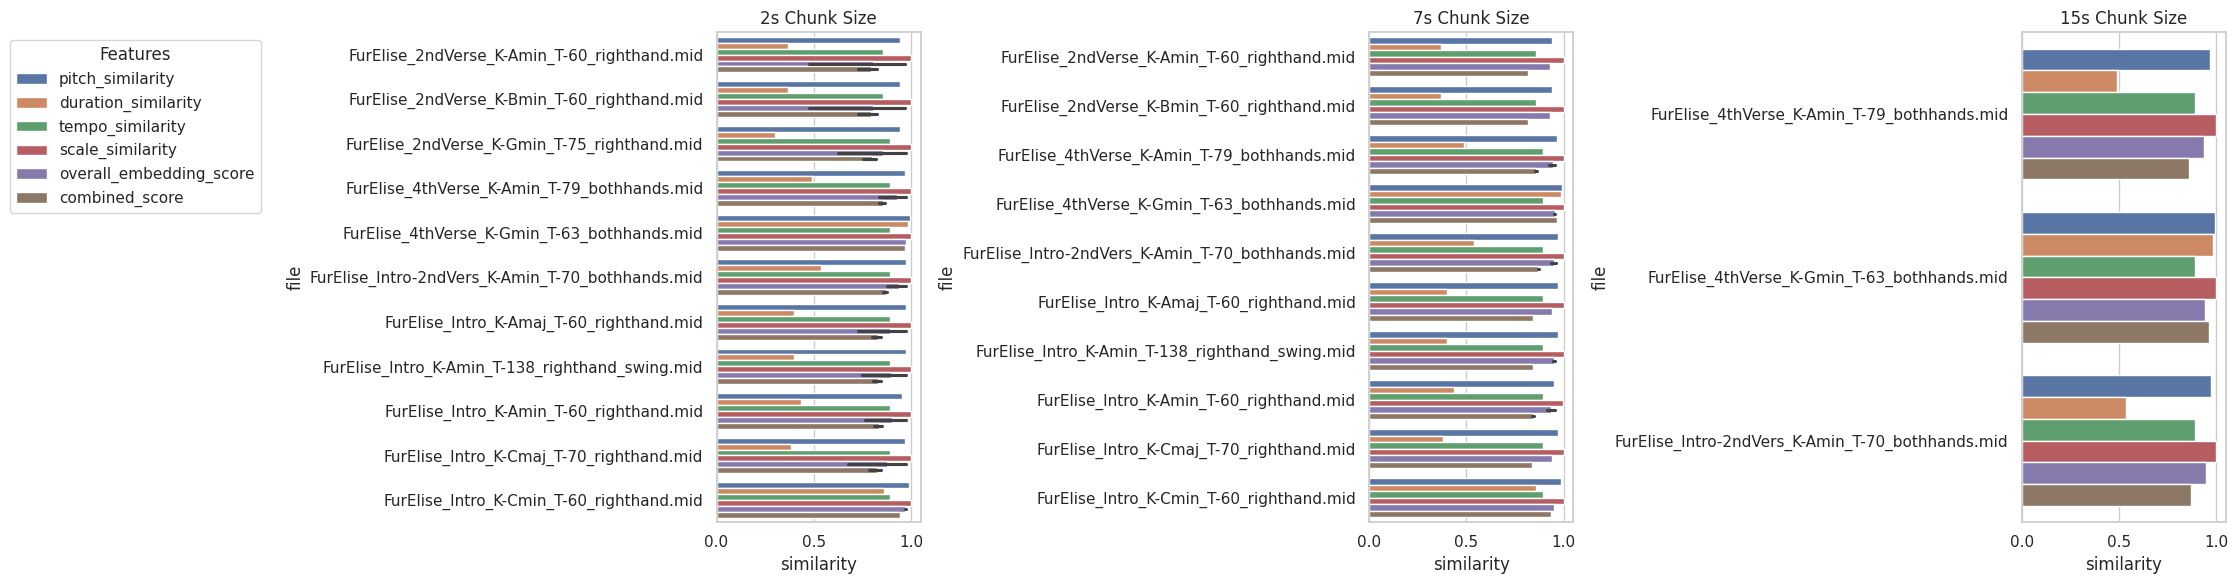

In [14]:
##########################
# Section 4 - Combined plotting (updated for real metrics)
##########################

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

# Melt dataframe for plotting
df_plot = df.melt(
    id_vars=["file", "chunk_size_label"],  # include chunk_size_label
    value_vars=[
        "pitch_similarity",
        "duration_similarity",
        "tempo_similarity",
        "scale_similarity",
        "overall_embedding_score",  # per-chunk MERT embedding score
        "combined_score"            # overall combined score
    ],
    var_name="feature",
    value_name="similarity"
)

# Helper: split files by low/med/high based on overall similarity
def get_split_files(df, col, split):
    sorted_files = df.sort_values(col)["file"].values
    n = len(sorted_files)
    if split == "low":
        return sorted_files[:n//3]
    elif split == "med":
        return sorted_files[n//3:2*n//3]
    elif split == "high":
        return sorted_files[2*n//3:]
    else:
        return sorted_files

# Create figure (1 row, 4 columns: legend + 3 plots)
fig, axes = plt.subplots(
    1, 4,
    figsize=(22, 6),
    gridspec_kw={'width_ratios':[0.2, 1, 1, 1]}
)

# Hide first axis (for legend only)
axes[0].axis('off')

# --- Plot Low / Medium / High chunk size groups ---
chunk_labels = [2, 7, 15]  # low, med, high durations
for i, chunk_sec in enumerate(chunk_labels):
    sns.barplot(
        x="similarity",
        y="file",
        hue="feature",
        data=df_plot[df_plot["chunk_size_label"] == chunk_sec],  # use chunk_size_label from df_plot itself
        ax=axes[i+1]
    )
    axes[i+1].set_title(f"{chunk_sec}s Chunk Size")
    axes[i+1].legend_.remove()

# --- Single legend in first column ---
handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Features")
axes[0].axis('off')

plt.tight_layout()
plt.show()

Best file: FurElise_4thVerse_K-Gmin_T-63_bothhands.mid with chunk size 2s
Worst file: FurElise_2ndVerse_K-Amin_T-60_righthand.mid with chunk size 2s


In [16]:
# --- Identify best and worst files based on combined_score ---
best_row = df.loc[df["combined_score"].idxmax()]
worst_row = df.loc[df["combined_score"].idxmin()]

best_file = best_row["file"]
best_chunk = best_row["chunk_size_label"]

worst_file = worst_row["file"]
worst_chunk = worst_row["chunk_size_label"]

print(f"Best file: {best_file} with chunk size {best_chunk}s")
print(f"Worst file: {worst_file} with chunk size {worst_chunk}s")
# --- Identify best and worst files based on combined_score ---
best_row = df.loc[df["combined_score"].idxmax()]
worst_row = df.loc[df["combined_score"].idxmin()]

best_file = best_row["file"]
best_chunk = best_row["chunk_size_label"]

worst_file = worst_row["file"]
worst_chunk = worst_row["chunk_size_label"]

print(f"Best file: {best_file} with chunk size {best_chunk}s")
print(f"Worst file: {worst_file} with chunk size {worst_chunk}s")

Best file: FurElise_4thVerse_K-Gmin_T-63_bothhands.mid with chunk size 2s
Worst file: FurElise_2ndVerse_K-Amin_T-60_righthand.mid with chunk size 2s


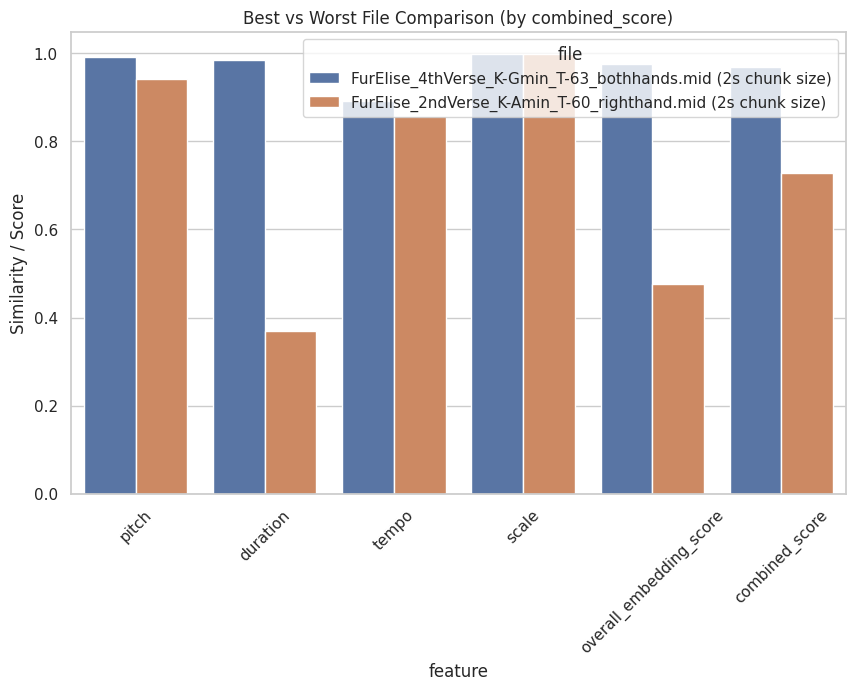

In [19]:
# Prepare DataFrame for best vs worst plot with chunk size in file label
best_worst_df = pd.DataFrame([
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "pitch", "similarity": best_row["pitch_similarity"]},
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "duration", "similarity": best_row["duration_similarity"]},
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "tempo", "similarity": best_row["tempo_similarity"]},
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "scale", "similarity": best_row["scale_similarity"]},
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "overall_embedding_score", "similarity": best_row["overall_embedding_score"]},
    {"file": f"{best_file} ({best_chunk}s chunk size)", "feature": "combined_score", "similarity": best_row["combined_score"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "pitch", "similarity": worst_row["pitch_similarity"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "duration", "similarity": worst_row["duration_similarity"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "tempo", "similarity": worst_row["tempo_similarity"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "scale", "similarity": worst_row["scale_similarity"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "overall_embedding_score", "similarity": worst_row["overall_embedding_score"]},
    {"file": f"{worst_file} ({worst_chunk}s chunk size)", "feature": "combined_score", "similarity": worst_row["combined_score"]},
])

# Plot best vs worst
plt.figure(figsize=(10,6))
sns.barplot(x="feature", y="similarity", hue="file", data=best_worst_df)
plt.title("Best vs Worst File Comparison (by combined_score)")
plt.xticks(rotation=45)
plt.ylabel("Similarity / Score")
plt.show()